#### 1. Model config params

In [1]:
model_type = 'forward'
dataset_csv = 'simulation_results.csv'
input_size = 8
output_size = 3

#### 2. Train

Using device: cpu

Scaling applied:
Features: standard
Targets: standard

 Forward model was initialized with input_size=8, output_size=3
Starting training with scaled data...
Epoch [10/250], Train Loss: 1.335478, Val Loss: 1.150548
Epoch [20/250], Train Loss: 1.259457, Val Loss: 0.847078
Epoch [30/250], Train Loss: 1.332859, Val Loss: 0.749793
Epoch [40/250], Train Loss: 1.129770, Val Loss: 0.649627
Epoch [50/250], Train Loss: 1.175109, Val Loss: 0.676424
Epoch [60/250], Train Loss: 1.088812, Val Loss: 0.605297
Epoch [70/250], Train Loss: 1.180274, Val Loss: 0.636075
Epoch [80/250], Train Loss: 1.035659, Val Loss: 0.708054
Epoch [90/250], Train Loss: 1.276872, Val Loss: 0.633036
Epoch [100/250], Train Loss: 1.140315, Val Loss: 0.639502
Epoch [110/250], Train Loss: 0.934977, Val Loss: 0.478468
Epoch [120/250], Train Loss: 1.100137, Val Loss: 0.524387
Epoch [130/250], Train Loss: 1.050600, Val Loss: 0.561367
Epoch [140/250], Train Loss: 0.965535, Val Loss: 0.507489
Epoch [150/250], Trai

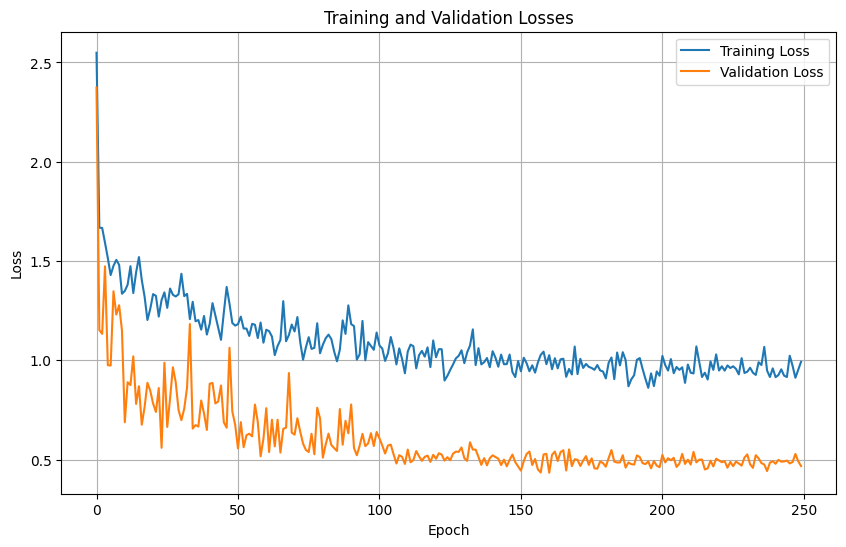


=== Test Results (Original Scale) ===
MSE Loss: 0.093890
RMSE: 0.042245
MAE: 0.019835

=== Per-Target Metrics (Original Scale) ===

 poisson:
  MSE: 0.001309
  RMSE: 0.036178
  MAE: 0.024966
  MAPE: 35.13%
  R²: 0.981721

 young:
  MSE: 0.004025
  RMSE: 0.063443
  MAE: 0.031052
  MAPE: 16.50%
  R²: 0.969598

 volume_frac:
  MSE: 0.000020
  RMSE: 0.004476
  MAE: 0.003486
  MAPE: 3.21%
  R²: 0.983015


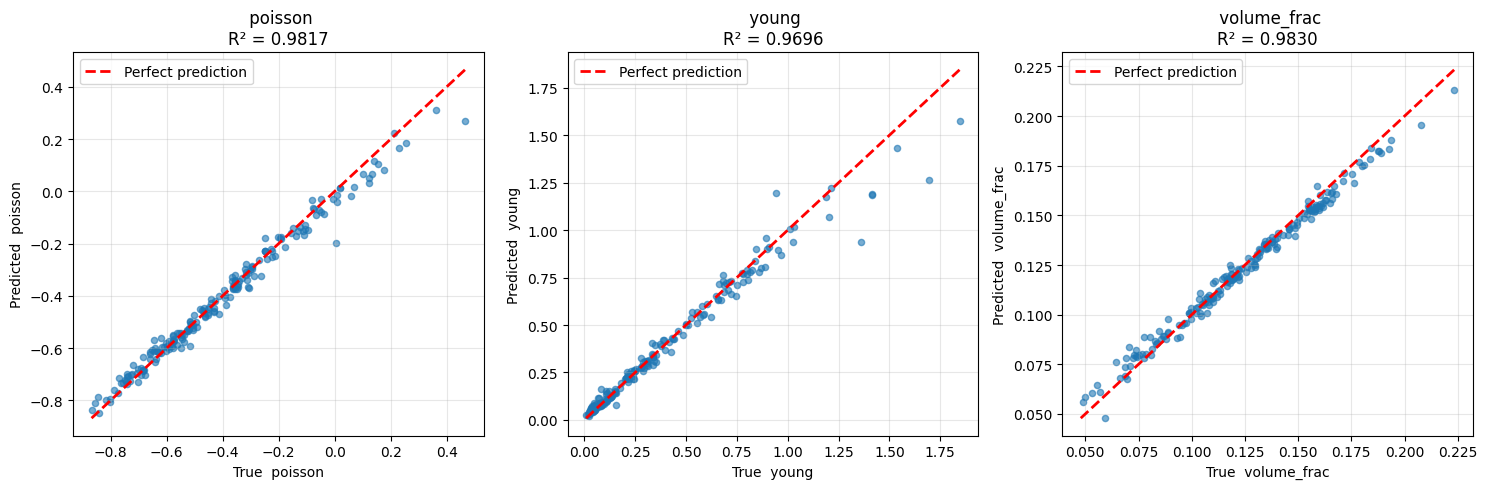

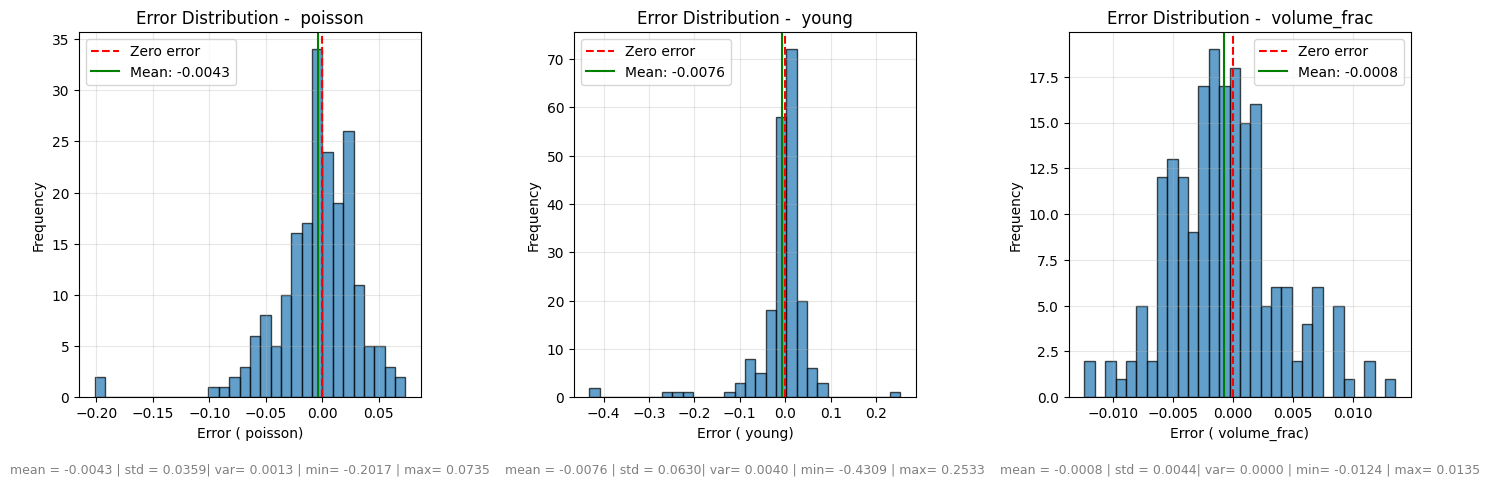

Model and scaler saved to forward_model_with_scaler.pth


In [2]:
from trainer import Trainer
trainer = Trainer(model_type, dataset_csv, input_size, output_size, 
                 learning_rate=2e-2, num_epochs = 250,
                 feature_scaler_type='standard', target_scaler_type='standard')

trainer.train()

#### 3. Loading from checkpoint file

[2.5486982829230174, 1.6678891713278634, 1.6666250256129673, 1.5923154299599784, 1.5149535819462367, 1.4295353712354388, 1.4758729512350899, 1.5058159351348877, 1.4805137375422885, 1.3354780994142805, 1.3492635290963308, 1.3808651154381888, 1.473938603401184, 1.338901902607509, 1.4433855165754046, 1.5198121983664377, 1.404282112802778, 1.3204552030563355, 1.2032025289535522, 1.2594571563175747, 1.3334114313125611, 1.3248033053534372, 1.2203611952917917, 1.3038517836162022, 1.3423368869509016, 1.2644145679473877, 1.361552106993539, 1.3301431846618652, 1.3214776154926846, 1.332859204156058, 1.4358681174686976, 1.3233299793515887, 1.3346357182094029, 1.207545156478882, 1.2947918701171874, 1.1967294876916068, 1.202878225190299, 1.154640895979745, 1.2234957136426654, 1.1297696113586426, 1.1832745722361973, 1.2880083022798812, 1.2264690358298165, 1.1653027834211076, 1.1035084853853498, 1.2412936176572527, 1.3693682432174683, 1.2850687367575508, 1.188167280469622, 1.175109464100429, 1.1821596

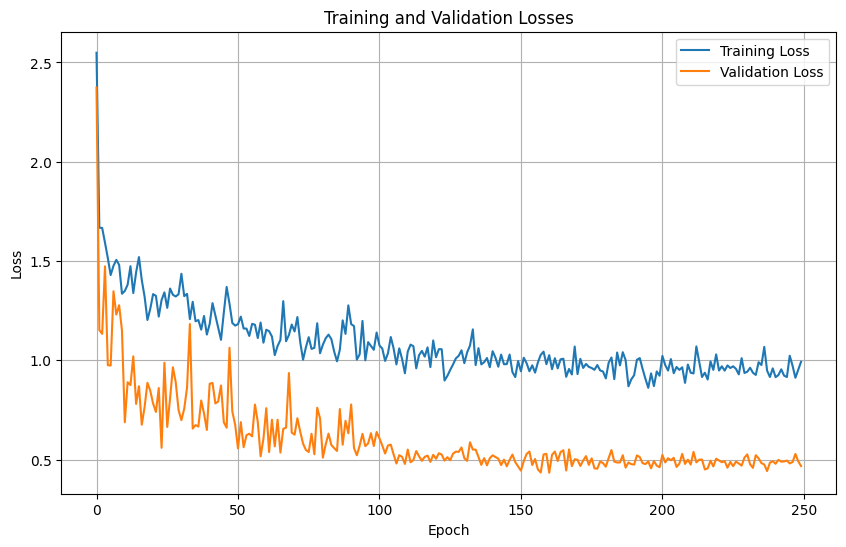

In [3]:
from trainer import Trainer
trainer = Trainer(model_type, dataset_csv, input_size, output_size, 
                 learning_rate=2e-2, num_epochs = 100,
                 feature_scaler_type='standard', target_scaler_type='standard')

model_path = 'forward_model_with_scaler.pth'
train_losses = trainer.get_field_from_checkpoint('train_losses')
val_losses = trainer.get_field_from_checkpoint('val_losses')
print(train_losses)
print(val_losses)
target_scaler = trainer.get_field_from_checkpoint('target_scaler')
print(target_scaler.mean_.shape)
scaler = trainer.get_field_from_checkpoint('scaler')
print(scaler.feature_scaler.mean_.shape)
trainer.plot_losses(train_losses, val_losses)